In [1]:
import torch
from colpali_engine.models import ColIdefics3, ColIdefics3Processor
from transformers import AutoModel, AutoProcessor, AutoTokenizer
from datasets import load_dataset
from tqdm import tqdm

from transformers.utils.import_utils import is_flash_attn_2_available
from colpali_engine.models import ColQwen2, ColQwen2Processor

from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from umap import UMAP
from matplotlib.patches import Patch
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import NearestNeighbors
import copy
import seaborn as sns


/Users/bhasircioglu/mumoRAG-attacks/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = 'mps'
model = AutoModel.from_pretrained('jinaai/jina-clip-v2', trust_remote_code=True, device_map=device)



/Users/bhasircioglu/.cache/huggingface/modules/transformers_modules/jinaai/jina-clip-implementation/51f02de9f2cf8afcd3bac4ce996859ba96f9f8e9/modeling_clip.py:137: UserWarning: Flash attention requires CUDA, disabling
  warnings.warn('Flash attention requires CUDA, disabling')
/Users/bhasircioglu/.cache/huggingface/modules/transformers_modules/jinaai/jina-clip-implementation/51f02de9f2cf8afcd3bac4ce996859ba96f9f8e9/modeling_clip.py:172: UserWarning: xFormers requires CUDA, disabling
  warnings.warn('xFormers requires CUDA, disabling')


In [7]:
ds = load_dataset("vidore/syntheticDocQA_artificial_intelligence_test", split="test")
ds

Dataset({
    features: ['query', 'image', 'image_filename', 'answer', 'page', 'model', 'prompt', 'source'],
    num_rows: 1000
})

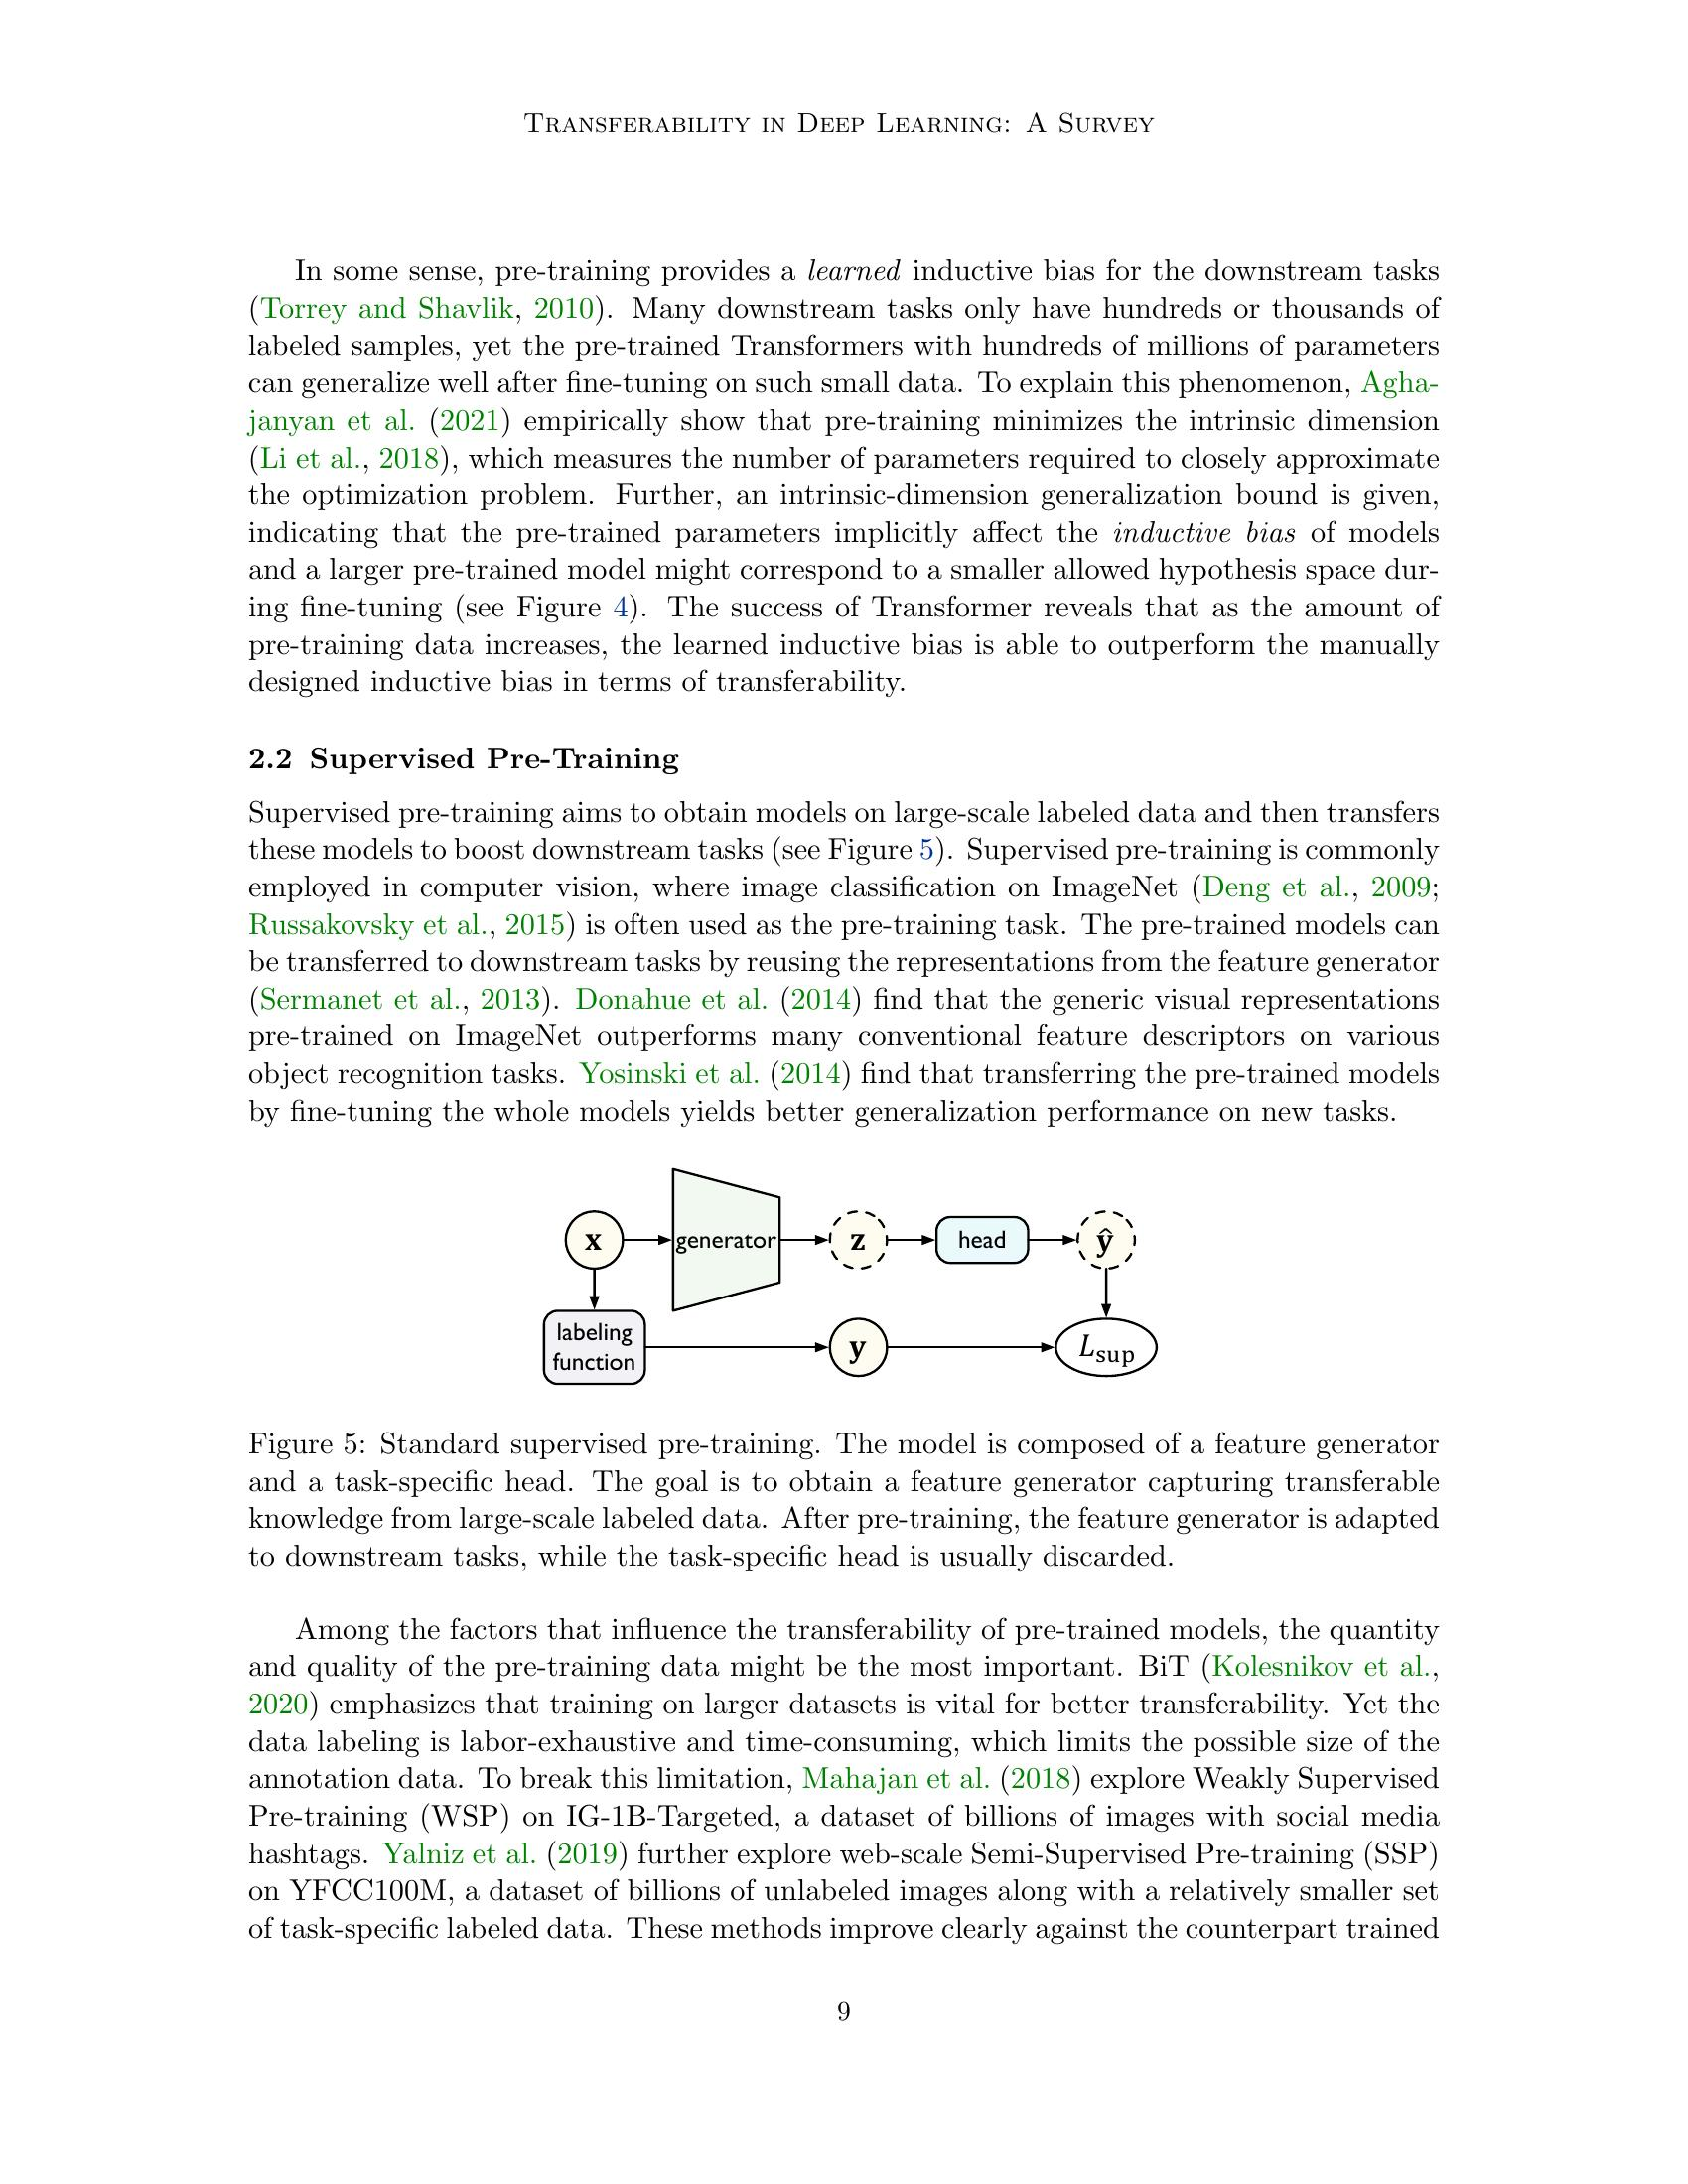

In [17]:
ds['image'][150]

In [3]:
ds = load_dataset("vidore/syntheticDocQA_artificial_intelligence_test", split="test[:100]")

ds = ds.map(lambda example, idx: {'id': idx}, with_indices=True)

ds_passages = ds.remove_columns(
    [col for col in ds.column_names if col not in ['image', 'image_hash', 'id']]
)
ds_queries = ds.remove_columns(
    [col for col in ds.column_names if col not in ['query', 'id']]
)

queries = list(ds_queries['query'])
passages = list(ds_passages['image'])

#####

dataloader = DataLoader(
    dataset=queries,
    batch_size=1,
    shuffle=False,
)

query_embeddings = []

with torch.no_grad():
    for batch_query in tqdm(dataloader, desc="Forward pass queries...", leave=False):
        embeddings_query = model.encode_text(batch_query, truncate_dim=128)
        query_embeddings.append(np.array(embeddings_query))

query_embeddings = np.array(query_embeddings)
query_embeddings = query_embeddings[:,0,:]


dataloader = DataLoader(
    dataset=passages,
    batch_size=2,
    shuffle=False,
)

image_embeddings = []

with torch.no_grad():
    for batch_doc in tqdm(passages, desc="Forward pass images...", leave=False):
        embeddings_doc = model.encode_image(batch_doc.resize((512,512)), truncate_dim=128)
        image_embeddings.append(np.array(embeddings_doc))

image_embeddings = np.array(image_embeddings)



Forward pass images...:   0%|          | 0/100 [00:00<?, ?it/s]           Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [4]:
#Permuting embeddings:
perm = np.random.permutation(len(query_embeddings))
query_embeddings = [query_embeddings[i] for i in perm]
image_embeddings = [image_embeddings[i] for i in perm]

# Sample data: group1 and group2 are lists of [1, X, 128] tensors
group1 = image_embeddings
group2 = query_embeddings

X_jina = np.concatenate([group1, group2], axis=0)


In [40]:
umap_model = UMAP(
    n_components=2,
    n_neighbors=5,        # Controls local vs global structure balance
    min_dist=0.01,          # Minimum distance between embedded points
    metric='cosine',    # Distance metric (adjust based on data)
    random_state=42
)
X_embedded_jina = umap_model.fit_transform(X_jina)

/Users/bhasircioglu/mumoRAG-attacks/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/bhasircioglu/mumoRAG-attacks/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [41]:
# Visualization with distinct colors

import matplotlib as mpl
mpl.use('pgf')

mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  # or "xelatex"/"lualatex" if you prefer
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False,
})
labels = np.array([0]*len(group1) + [1]*len(group2))

colors = np.array(['red', 'green'])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_embedded_jina[:, 0], 
    X_embedded_jina[:, 1], 
    c=colors[labels], 
    alpha=1,
    edgecolors='w',
    linewidth=0.5,
    s=100
)

plt.tick_params(axis='both', which='major', labelsize=20)  # Set large font size for tick labels



legend_elements = [
    Patch(facecolor='red', edgecolor='w', label='Image Embeddings'),
    Patch(facecolor='green', edgecolor='w', label='Query Embeddings')
]
plt.legend(handles=legend_elements, loc="best", fontsize=15)




plt.title(f'UMAP Visualization of Jina-Clip Retrieval Scores, n_neighbors:{umap_model.n_neighbors}, min_dist:{umap_model.min_dist}')

#plt.title('t-SNE Visualization of Embeddings')
#plt.xlabel('UMAP Dimension 1', fontsize=25)
#plt.ylabel('UMAP Dimension 2', fontsize=25)
plt.grid(alpha=0.2)


metric='cosine'
original_distances = squareform(pdist(X_jina, metric=metric))

# Set number of neighbors to show per point
n_neighbors_to_draw = 1

# Find k nearest neighbors in original space
nn = NearestNeighbors(n_neighbors=n_neighbors_to_draw + 1, metric=metric)  # +1 because point is neighbor to itself
nn.fit(X_jina)
distances, indices = nn.kneighbors(X_jina)

nn_not_image_counter = 0
# Draw lines and annotate distances
for i in range(int(len(X_jina)/2),len(X_jina)):
    my_list = list(indices[i][1:])
    #my_list.append(np.random.randint(0, len(X_jina)))
    for j in my_list:  # skip self (first neighbor)
        #j = np.random.randint(0, len(cos_data))
        if i == j or np.random.randint(0,10) < 0:
            continue
        x1, y1 = X_embedded_jina[i]
        x2, y2 = X_embedded_jina[j]
        dist = original_distances[i, j]
        
        # Draw line between points
        #plt.plot([x1, x2], [y1, y2], 'green', linestyle='--', linewidth=0.2)
        
        # Annotate distance near the midpoint
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        #plt.text(mx, my, f"{dist:.2f}", fontsize=8, color='black', ha='center')

    if not i-100 in my_list:  # i+100 is the corresponding image for query i
        nn_not_image_counter += 1
        x1, y1 = X_embedded_jina[i]
        x2, y2 = X_embedded_jina[i-100]
        dist = original_distances[i, i-100]
        
        # Draw line between points
        #plt.plot([x1, x2], [y1, y2], 'red', linestyle='--', linewidth=0.2)
        
        # Annotate distance near the midpoint
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        #plt.text(mx, my, f"{dist:.2f}", fontsize=8, color='blue', ha='center')

print(f"Number of lines drawn for non-image neighbors: {nn_not_image_counter}")

rand_ind = np.random.randint(0,10_000)
#plt.show()
plt.savefig(f'jina_umap_noQuery_{rand_ind}.pgf')
plt.savefig(f'jina_umap_noQuery_{rand_ind}.pdf')

Number of lines drawn for non-image neighbors: 91


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [18]:
device = 'mps'
model_name = "openai/clip-vit-large-patch14"
model = AutoModel.from_pretrained(model_name).to(device)
processor = AutoProcessor.from_pretrained(model_name, use_fast=True)
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [19]:
ds = load_dataset("vidore/syntheticDocQA_artificial_intelligence_test", split="test[:100]")

ds = ds.map(lambda example, idx: {'id': idx}, with_indices=True)

ds_passages = ds.remove_columns(
    [col for col in ds.column_names if col not in ['image', 'image_hash', 'id']]
)
ds_queries = ds.remove_columns(
    [col for col in ds.column_names if col not in ['query', 'id']]
)

queries = list(ds_queries['query'])
passages = list(ds_passages['image'])

#####
dataloader = DataLoader(
    dataset=queries,
    batch_size=1,
    shuffle=False,
)

query_embeddings = []

with torch.no_grad():
    for batch_query in tqdm(dataloader, desc="Forward pass queries...", leave=False):
        embeddings_query = model.get_text_features(**tokenizer(batch_query, return_tensors="pt", truncation=True, padding=True).to(device)) 
        query_embeddings.append(embeddings_query.to('cpu').numpy())

query_embeddings = np.array(query_embeddings)
query_embeddings = query_embeddings[:,0,:]


dataloader = DataLoader(
    dataset=passages,
    batch_size=2,
    shuffle=False,
)

image_embeddings = []

with torch.no_grad():
    for batch_doc in tqdm(passages, desc="Forward pass images...", leave=False):
        image_input_emb = processor(images=batch_doc, return_tensors='pt').to(device)

        embeddings_doc = model.get_image_features(**image_input_emb)
        #embeddings_doc = model.encode_image(batch_doc.resize((512,512)), truncate_dim=128)
        image_embeddings.append(embeddings_doc.to('cpu').numpy())

image_embeddings = np.array(image_embeddings)
image_embeddings = image_embeddings[:,0,:]


In [20]:
#Permuting embeddings:
perm = np.random.permutation(len(query_embeddings))
query_embeddings = [query_embeddings[i] for i in perm]
image_embeddings = [image_embeddings[i] for i in perm]

# Sample data: group1 and group2 are lists of [1, X, 128] tensors
group1 = image_embeddings
group2 = query_embeddings

X_clip = np.concatenate([group1, group2], axis=0)

# t-SNE transformation
#tsne = TSNE(n_components=2, perplexity=25, random_state=42)
#X_embedded_clip = tsne.fit_transform(X)



In [36]:
umap_model = UMAP(
    n_components=2,
    n_neighbors=5,        # Controls local vs global structure balance
    min_dist=0.01,          # Minimum distance between embedded points
    metric='cosine',    # Distance metric (adjust based on data)
    random_state=42
)
X_embedded_clip = umap_model.fit_transform(X_clip)

/Users/bhasircioglu/mumoRAG-attacks/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/bhasircioglu/mumoRAG-attacks/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [39]:
# Visualization with distinct colors

import matplotlib as mpl
mpl.use('pgf')

mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  # or "xelatex"/"lualatex" if you prefer
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False,
})
labels = np.array([0]*len(group1) + [1]*len(group2))

colors = np.array(['red', 'green'])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_embedded_clip[:, 0], 
    X_embedded_clip[:, 1], 
    c=colors[labels], 
    alpha=1,
    edgecolors='w',
    linewidth=0.5,
    s=100
)

plt.tick_params(axis='both', which='major', labelsize=20)  # Set large font size for tick labels



legend_elements = [
    Patch(facecolor='red', edgecolor='w', label='Image Embeddings'),
    Patch(facecolor='green', edgecolor='w', label='Query Embeddings')
]
plt.legend(handles=legend_elements, loc="best", fontsize=15)




plt.title(f'UMAP Visualization of Clip Retrieval Scores, n_neighbors:{umap_model.n_neighbors}, min_dist:{umap_model.min_dist}')

#plt.title('t-SNE Visualization of Embeddings')
#plt.xlabel('UMAP Dimension 1', fontsize=25)
#plt.ylabel('UMAP Dimension 2', fontsize=25)
plt.grid(alpha=0.2)


metric='cosine'
original_distances = squareform(pdist(X_clip, metric=metric))

# Set number of neighbors to show per point
n_neighbors_to_draw = 1

# Find k nearest neighbors in original space
nn = NearestNeighbors(n_neighbors=n_neighbors_to_draw + 1, metric=metric)  # +1 because point is neighbor to itself
nn.fit(X_clip)
distances, indices = nn.kneighbors(X_clip)

nn_not_image_counter = 0
# Draw lines and annotate distances
for i in range(int(len(X_clip)/2),len(X_clip)):
    my_list = list(indices[i][1:])
    #my_list.append(np.random.randint(0, len(X_clip)))
    for j in my_list:  # skip self (first neighbor)
        #j = np.random.randint(0, len(cos_data))
        if i == j or np.random.randint(0,10) < 0:
            continue
        x1, y1 = X_embedded_clip[i]
        x2, y2 = X_embedded_clip[j]
        dist = original_distances[i, j]
        
        # Draw line between points
        #plt.plot([x1, x2], [y1, y2], 'green', linestyle='--', linewidth=0.2)
        
        # Annotate distance near the midpoint
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        #plt.text(mx, my, f"{dist:.2f}", fontsize=8, color='black', ha='center')

    if not i-100 in my_list:  # i+100 is the corresponding image for query i
        nn_not_image_counter += 1
        x1, y1 = X_embedded_clip[i]
        x2, y2 = X_embedded_clip[i-100]
        dist = original_distances[i, i-100]
        
        # Draw line between points
        #plt.plot([x1, x2], [y1, y2], 'red', linestyle='--', linewidth=0.2)
        
        # Annotate distance near the midpoint
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        #plt.text(mx, my, f"{dist:.2f}", fontsize=8, color='blue', ha='center')

print(f"Number of lines drawn for non-image neighbors: {nn_not_image_counter}")

rand_ind = np.random.randint(0,10_000)
#plt.show()
plt.savefig(f'clip_umap_noQuery_{rand_ind}.pgf')
plt.savefig(f'clip_umap_noQuery_{rand_ind}.pdf')

Number of lines drawn for non-image neighbors: 100


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [2]:
from transformers import ColPaliForRetrieval, ColPaliProcessor

model_name = "vidore/colpali-v1.3-hf"
model = ColPaliForRetrieval.from_pretrained(
    model_name,
    torch_dtype=torch.float32,
    device_map="mps",  # or "mps" if on Apple Silicon
).eval()

processor = ColPaliProcessor.from_pretrained(model_name)

Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.44s/it]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
#from vidore_benchmark.utils.data_utils import deduplicate_dataset_rows

# Evaluate on a single dataset
#ds = load_dataset("vidore/tabfquad_test_subsampled", split="test[:10]")
ds = load_dataset("vidore/syntheticDocQA_artificial_intelligence_test", split="test[:100]")

ds = ds.map(lambda example, idx: {'id': idx}, with_indices=True)

ds_passages = ds.remove_columns(
    [col for col in ds.column_names if col not in ['image', 'image_hash', 'id']]
)
ds_queries = ds.remove_columns(
    [col for col in ds.column_names if col not in ['query', 'id']]
)
#ds_queries = deduplicate_dataset_rows(ds=ds_queries, target_column='query')

queries = list(ds_queries['query'])

dataloader = DataLoader(
    dataset=queries,
    batch_size=1,
    shuffle=False,
    collate_fn=processor.process_queries
)

query_embeddings = []

with torch.no_grad():
    for batch_query in tqdm(dataloader, desc="Forward pass queries...", leave=False):
        batch_query = batch_query.to(model.device)
        embeddings_query = model(**batch_query).embeddings.to("cpu")
        #print(f"input:{batch_query['input_ids'].shape}")
        #print(f"output {embeddings_query.shape}")
        query_embeddings.extend(list(torch.unbind(embeddings_query)))



In [4]:
passages = list(ds_passages['image'])

dataloader = DataLoader(
    dataset=passages,
    batch_size=1,
    shuffle=False,
    collate_fn=processor.process_images
)

image_embeddings = []

with torch.no_grad():
    for batch_doc in tqdm(dataloader, desc="Forward pass images...", leave=False):
        batch_doc = batch_doc.to(torch.float32).to(model.device)
        embeddings_doc = model(**batch_doc).embeddings.to("cpu")
        #print(embeddings_doc.shape)
        image_embeddings.extend(list(torch.unbind(embeddings_doc)))


In [5]:
suffix = 'colpali'
torch.save(query_embeddings, f"query_embeddings_{suffix}.pt")
torch.save(image_embeddings, f"passage_embeddings_{suffix}.pt")

In [42]:
suffix = 'colpali'
query_embeddings = torch.load(f"query_embeddings_{suffix}.pt")
image_embeddings = torch.load(f"passage_embeddings_{suffix}.pt")

In [43]:
from typing import ClassVar, List, Optional, Union

def score_retrieval(
        query_embeddings: Union["torch.Tensor", List["torch.Tensor"]],
        passage_embeddings: Union["torch.Tensor", List["torch.Tensor"]],
        batch_size: int = 128,
        output_dtype: Optional["torch.dtype"] = None,
        output_device: Union["torch.device", str] = "cpu",
    ) -> "torch.Tensor":
    
        if len(query_embeddings) == 0:
            raise ValueError("No queries provided")
        if len(passage_embeddings) == 0:
            raise ValueError("No passages provided")

        if query_embeddings[0].device != passage_embeddings[0].device:
            raise ValueError("Queries and passages must be on the same device")

        if query_embeddings[0].dtype != passage_embeddings[0].dtype:
            raise ValueError("Queries and passages must have the same dtype")

        if output_dtype is None:
            output_dtype = query_embeddings[0].dtype    

        scores: List[torch.Tensor] = []

        for i in range(0, len(query_embeddings), batch_size):
            batch_scores: List[torch.Tensor] = []
            batch_queries = torch.nn.utils.rnn.pad_sequence(
                query_embeddings[i : i + batch_size], batch_first=True, padding_value=0
            )
            for j in range(0, len(passage_embeddings), batch_size):
                batch_passages = torch.nn.utils.rnn.pad_sequence(
                    passage_embeddings[j : j + batch_size], batch_first=True, padding_value=0
                )
                unnorm_score = torch.einsum("bnd,csd->bcns", batch_queries, batch_passages).max(dim=3)[0]
                print(f"unnorm_score: {unnorm_score.shape}")
                batch_scores.append(
                    unnorm_score.sum(dim=2)
                )
            scores.append(torch.cat(batch_scores, dim=1).to(output_dtype).to(output_device))

        return torch.cat(scores, dim=0)

In [44]:
#Permuting embeddings:
perm = np.random.permutation(len(query_embeddings))
query_embeddings = [query_embeddings[i] for i in perm]
image_embeddings = [image_embeddings[i] for i in perm]
all_embeddings_norm = copy.deepcopy(query_embeddings) + copy.deepcopy(image_embeddings)
all_embeddings = copy.deepcopy(query_embeddings) + copy.deepcopy(image_embeddings)


for i in range(len(all_embeddings_norm)):
    #all_embeddings[i] = all_embeddings[i].float().to("mps")
    all_embeddings_norm[i] = all_embeddings_norm[i]/all_embeddings_norm[i].shape[0]

scores = score_retrieval(all_embeddings_norm, all_embeddings)
scores_sym = 1 - 0.5*(scores + scores.T) + 1e-6

unnorm_score: torch.Size([128, 128, 1030])
unnorm_score: torch.Size([128, 72, 1030])
unnorm_score: torch.Size([72, 128, 1030])
unnorm_score: torch.Size([72, 72, 1030])


In [40]:
# Sample data: group1 and group2 are lists of [1, X, 128] tensors
group1 = image_embeddings
group2 = query_embeddings

# Combine and label data
group1_combined_all = np.concatenate([t.float() for t in group1], axis=0)  # Shape: [N1, 128]
group2_combined_all = np.concatenate([t.float() for t in group2], axis=0)  # Shape: [N2, 128]

X_colpali = np.concatenate([group1_combined_all, group2_combined_all], axis=0)

# t-SNE transformation
#tsne = TSNE(n_components=2, perplexity=25, random_state=42)
#X_embedded_all = tsne.fit_transform(X)



In [45]:
scores_sym = 1 - 0.5*(scores + scores.T) + 1e-6

In [46]:
sns.heatmap(scores.numpy(), square=True, cmap='plasma')
plt.show()

plt.figure()
sns.heatmap(scores_sym.numpy(), square=True, cmap='plasma')
plt.show()


/var/folders/c_/s6vz44t949d__4tw2j76q51m0000gr/T/ipykernel_57439/819741277.py:2: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/c_/s6vz44t949d__4tw2j76q51m0000gr/T/ipykernel_57439/819741277.py:6: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()


In [50]:
umap_model = UMAP(
    n_components=2,
    n_neighbors=5,        # Controls local vs global structure balance
    min_dist=0.01,          # Minimum distance between embedded points
    metric='precomputed',    # Distance metric (adjust based on data)
    #random_state=42
)
X_embedded_all = umap_model.fit_transform(scores_sym)

/Users/bhasircioglu/mumoRAG-attacks/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/bhasircioglu/mumoRAG-attacks/.venv/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


In [51]:
import matplotlib as mpl
mpl.use('pgf')

mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  # or "xelatex"/"lualatex" if you prefer
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False,
})

labels = np.array([0]*100 + [1]*100)

colors = np.array(['green', 'red'])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_embedded_all[:, 0], 
    X_embedded_all[:, 1], 
    c=colors[labels], 
    alpha=1,
    edgecolors='w',
    linewidth=0.5,
    s=100
)

legend_elements = [
    Patch(facecolor='red', edgecolor='w', label='Image Embeddings'),
    Patch(facecolor='green', edgecolor='w', label='Query Embeddings')
]
plt.legend(handles=legend_elements, loc="best",fontsize=15)

n_neighbors_to_draw = 1

# Find k nearest neighbors in original space
nn = NearestNeighbors(n_neighbors=n_neighbors_to_draw + 1, metric='precomputed')  # +1 because point is neighbor to itself
nn.fit(scores_sym)
distances, indices = nn.kneighbors(scores_sym)

# Draw lines and annotate distances
nn_not_image_counter = 0
for i in range(int(len(all_embeddings)/2)):
    my_list = list(indices[i][1:])
    if len(my_list) == 0:
        print(i)
    if np.random.randint(0,10) < 0:
        my_list.append(np.random.randint(0, len(all_embeddings)))
    for point_ind, j in enumerate(my_list):  # skip self (first neighbor)
        #j = np.random.randint(0, len(cos_data))
        #if i == j or np.random.randint(0,10) < 0:
        #    continue
        x1, y1 = X_embedded_all[i]
        x2, y2 = X_embedded_all[j]
        dist = scores_sym[i, j]
        
        if point_ind > 0:
            line_color = 'red'
            text_color = 'red'
        else:
            line_color = 'gray'
            text_color = 'black'
        # Draw line between points
        #plt.plot([x1, x2], [y1, y2], line_color, linestyle='--', linewidth=0.5)
        
        if np.linalg.norm(np.array([x1, y1]) - np.array([x2, y2]),ord=2) < 0.5:
            step = 0.5
            eps_x = np.random.uniform(-step, step)
            eps_y = np.random.uniform(-step, step)
        else:
            eps_x = 0
            eps_y = 0
        # Annotate distance near the midpoint
        mx, my = (x1 + x2) / 2 + eps_x, (y1 + y2) / 2 + eps_y
        #plt.text(mx, my, f"{dist:.2f}", fontsize=8, color=text_color, ha='center')

    if not i+100 in my_list:  # i+100 is the corresponding image for query i
        nn_not_image_counter += 1
        x1, y1 = X_embedded_all[i]
        x2, y2 = X_embedded_all[i+100]
        dist = scores_sym[i, i+100]
        
        # Draw line between points
        plt.plot([x1, x2], [y1, y2], 'blue', linestyle='--', linewidth=0.5)
        
        # Annotate distance near the midpoint
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        #plt.text(mx, my, f"{dist:.2f}", fontsize=8, color='blue', ha='center')

plt.title(f'UMAP Visualization of ColPali Retrieval Scores, n_neighbors:{umap_model.n_neighbors}, min_dist:{umap_model.min_dist}')
#plt.show()
rand_ind = np.random.randint(0,10_000)


plt.savefig(f'colpali_umap_noQuery_{rand_ind}.pgf')
plt.savefig(f'colpali_umap_noQuery_{rand_ind}.pdf')
print(f'pdf saved with id: {rand_ind}') 
print(f"Number of queries that do not have the corresponding image in the nearest neighbors: {nn_not_image_counter}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


pdf saved with id: 8848
Number of queries that do not have the corresponding image in the nearest neighbors: 47


In [2]:
from transformers import AutoModelForImageTextToText, AutoProcessor
device = 'mps'
model_name = "Alibaba-NLP/gme-Qwen2-VL-2B-Instruct"

model = AutoModelForImageTextToText.from_pretrained(model_name).to(device).eval()
processor = AutoProcessor.from_pretrained(model_name, use_fast=True)
instruction = "You are a helpful AI model."


Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.03it/s]


In [9]:
#from vidore_benchmark.utils.data_utils import deduplicate_dataset_rows

# Evaluate on a single dataset
#ds = load_dataset("vidore/tabfquad_test_subsampled", split="test[:10]")
ds = load_dataset("vidore/syntheticDocQA_artificial_intelligence_test", split="test[:100]")

ds = ds.map(lambda example, idx: {'id': idx}, with_indices=True)

ds_passages = ds.remove_columns(
    [col for col in ds.column_names if col not in ['image', 'image_hash', 'id']]
)
ds_queries = ds.remove_columns(
    [col for col in ds.column_names if col not in ['query', 'id']]
)
#ds_queries = deduplicate_dataset_rows(ds=ds_queries, target_column='query')

queries = list(ds_queries['query'])

dataloader = DataLoader(
    dataset=queries,
    batch_size=1,
    shuffle=False,
)

query_embeddings = []

with torch.no_grad():
    for batch_query in tqdm(dataloader, desc="Forward pass queries...", leave=False):
        '''batch_query = batch_query.to(model.device)
        embeddings_query = model(**batch_query).embeddings.to("cpu")
        #print(f"input:{batch_query['input_ids'].shape}")
        #print(f"output {embeddings_query.shape}")
        query_embeddings.extend(list(torch.unbind(embeddings_query)))
'''
        assert isinstance(batch_query, list)
        msg = [f'<|im_start|>system\n{instruction}<|im_end|>\n<|im_start|>user\n{q}<|im_end|>\n<|im_start|>assistant\n<|endoftext|>' for q in batch_query]
        inputs = processor(text=msg, return_tensors="pt", padding=True, padding_side="left", truncation=True).to(device)
        outputs = model(**inputs, output_hidden_states=True)
        last_hidden_state = outputs.hidden_states[-1]
        embedding = last_hidden_state[:, -1].contiguous()
        embedding = torch.nn.functional.normalize(embedding, p=2, dim=1)
        query_embeddings.append(embedding)

In [13]:
import torchvision.transforms.v2 as T

passages = list(ds_passages['image'])

dataloader = DataLoader(
    dataset=passages,
    batch_size=1,
    shuffle=False,
    #collate_fn=processor.process_images
)

image_embeddings = []

with torch.no_grad():
    for batch_doc in tqdm(passages, desc="Forward pass images...", leave=False):
        image = [batch_doc]

        if isinstance(image, list):
            image = torch.cat([T.Resize((512,512))(T.PILToTensor()(im)).unsqueeze(0) for im in image], dim=0)
        n_image = 1 if len(image.shape) == 3 else image.shape[0]
        image_text = '<|vision_start|><|image_pad|><|vision_end|>'
        msg = [f'<|im_start|>system\n{instruction}<|im_end|>\n<|im_start|>user\n{image_text}<|im_end|>\n<|im_start|>assistant\n<|endoftext|>' for _ in range(n_image)]
        inputs = processor(text=msg, images=image, return_tensors="pt", padding=True, padding_side="left", truncation=True).to(device)
        outputs = model(**inputs, output_hidden_states=True)
        last_hidden_state = outputs.hidden_states[-1]
        embedding = last_hidden_state[:, -1]
        embedding = torch.nn.functional.normalize(embedding, p=2, dim=1)
        image_embeddings.append(embedding)

In [14]:
suffix = 'gme-qwen2'
torch.save(query_embeddings, f"query_embeddings_{suffix}.pt")
torch.save(image_embeddings, f"passage_embeddings_{suffix}.pt")

In [24]:
suffix = 'gme-qwen2'
query_embeddings = torch.load(f"query_embeddings_{suffix}.pt")
image_embeddings = torch.load(f"passage_embeddings_{suffix}.pt")

/var/folders/c_/s6vz44t949d__4tw2j76q51m0000gr/T/ipykernel_3683/81938502.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  query_embeddings = torch.load(f"query_embeddings

In [25]:
query_embeddings  = [q.cpu() for q in query_embeddings]
image_embeddings = [p.cpu() for p in image_embeddings]

query_embeddings = np.array(query_embeddings)
image_embeddings = np.array(image_embeddings)

X_qwen = np.concatenate([query_embeddings, image_embeddings], axis=0)
X_qwen = X_qwen[:,0,:]


In [26]:
umap_model = UMAP(
    n_components=2,
    n_neighbors=5,        # Controls local vs global structure balance
    min_dist=0.01,          # Minimum distance between embedded points
    metric='cosine',    # Distance metric (adjust based on data)
    random_state=42
)
X_embedded_qwen = umap_model.fit_transform(X_qwen)

/Users/bhasircioglu/mumoRAG-attacks/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/bhasircioglu/mumoRAG-attacks/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [29]:
# Visualization with distinct colors

import matplotlib as mpl
mpl.use('pgf')

mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  # or "xelatex"/"lualatex" if you prefer
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False,
})
labels = np.array([0]*len(image_embeddings) + [1]*len(query_embeddings))

colors = np.array(['green', 'red'])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_embedded_qwen[:, 0], 
    X_embedded_qwen[:, 1], 
    c=colors[labels], 
    alpha=1,
    edgecolors='w',
    linewidth=0.5,
    s=100
)

plt.tick_params(axis='both', which='major', labelsize=20)  # Set large font size for tick labels



legend_elements = [
    Patch(facecolor='red', edgecolor='w', label='Image Embeddings'),
    Patch(facecolor='green', edgecolor='w', label='Query Embeddings')
]
plt.legend(handles=legend_elements, loc="best", fontsize=15)




plt.title(f'UMAP Visualization of Qwen Retrieval Scores, n_neighbors:{umap_model.n_neighbors}, min_dist:{umap_model.min_dist}')

#plt.title('t-SNE Visualization of Embeddings')
#plt.xlabel('UMAP Dimension 1', fontsize=25)
#plt.ylabel('UMAP Dimension 2', fontsize=25)
plt.grid(alpha=0.2)


metric='cosine'
original_distances = squareform(pdist(X_qwen, metric=metric))

# Set number of neighbors to show per point
n_neighbors_to_draw = 1

# Find k nearest neighbors in original space
nn = NearestNeighbors(n_neighbors=n_neighbors_to_draw + 1, metric=metric)  # +1 because point is neighbor to itself
nn.fit(X_qwen)
distances, indices = nn.kneighbors(X_qwen)

nn_not_image_counter = 0
# Draw lines and annotate distances
for i in range(int(len(X_qwen)/2)):
    my_list = list(indices[i][1:])
    #my_list.append(np.random.randint(0, len(X_qwen)))
    for j in my_list:  # skip self (first neighbor)
        #j = np.random.randint(0, len(cos_data))
        if i == j or np.random.randint(0,10) < 0:
            continue
        x1, y1 = X_embedded_qwen[i]
        x2, y2 = X_embedded_qwen[j]
        dist = original_distances[i, j]
        
        # Draw line between points
        #plt.plot([x1, x2], [y1, y2], 'green', linestyle='--', linewidth=0.2)
        
        # Annotate distance near the midpoint
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        #plt.text(mx, my, f"{dist:.2f}", fontsize=8, color='black', ha='center')

    if not i+100 in my_list:  # i+100 is the corresponding image for query i
        nn_not_image_counter += 1
        x1, y1 = X_embedded_qwen[i]
        x2, y2 = X_embedded_qwen[i+100]
        dist = original_distances[i, i+100]
        
        # Draw line between points
        plt.plot([x1, x2], [y1, y2], 'blue', linestyle='--', linewidth=0.2)
        
        # Annotate distance near the midpoint
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        #plt.text(mx, my, f"{dist:.2f}", fontsize=8, color='blue', ha='center')

print(f"Number of lines drawn for non-image neighbors: {nn_not_image_counter}")

rand_ind = np.random.randint(0,10_000)
#plt.show()
plt.savefig(f'qwen_umap_noQuery_{rand_ind}.pgf')
plt.savefig(f'qwen_umap_noQuery_{rand_ind}.pdf')

Number of lines drawn for non-image neighbors: 48
